# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AbdulRaffayQureshi/FlyRank-ML-Intern/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Primary Research Question
*How can we algorithmically prioritize decaying or stagnant web URLs to optimize editorial resource allocation and support organic search traffic recovery?*

This project delivers a data-driven **decision-support** tool for content editorial teams. By modeling traffic decay non-linearly and combining historical performance with content age, we generate a ranked opportunity queue. This replaces subjective manual scheduling with empirical priority levels, aiming to direct copywriting resources to pages with the highest recovery potential.

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Configure plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Imports completed and environment configured successfully.")

Imports completed and environment configured successfully.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

### Data Slice and Safety Profile
We utilize the `content_refresh_anonymized.csv` dataset, representing a mid-panel cohort of web performance metrics. 

- **The Grain:** One row corresponds to a unique `content_id` (representing a specific URL) for a given `client_id` over a rolling historical performance window.
- **Target Label Creation:** The target proxy is a binary indicator (`is_declining_label`) constructed from `trend_direction` (equal to "down" indicating traffic decay).
- **Data Safety and Privacy:** All raw client domains, text queries, and identity identifiers have been strictly anonymized. Database keys are used exclusively for mapping, and no customer-identifying information is fed to the models.

In [6]:
# Locate data path dynamically
data_path = "data/raw/content_refresh_anonymized.csv"
if not os.path.exists(data_path):
    for path in ["../../data/raw/content_refresh_anonymized.csv", "../data/raw/content_refresh_anonymized.csv", "content_refresh_anonymized.csv"]:
        if os.path.exists(path):
            data_path = path
            break

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Could not find content_refresh_anonymized.csv. Please ensure it is in the repository data directory.")

# Load Raw Data
df = pd.read_csv(data_path)
print(f"Loaded {len(df)} rows and {len(df.columns)} columns.")

# Prepare Target Variable programmatically
df_clean = df.copy()
df_clean["is_declining_label"] = df_clean["trend_direction"].str.lower().eq("down").astype(int)

# Handle Missing Data Safely
df_clean["days_since_last_update"] = df_clean["days_since_last_update"].fillna(180)
df_clean["word_count"] = df_clean["word_count"].fillna(df_clean["word_count"].median())
df_clean["ctr"] = df_clean["ctr"].fillna(0.0)
df_clean["avg_position"] = df_clean["avg_position"].fillna(100.0)
df_clean["impressions_90d"] = df_clean["impressions_90d"].fillna(df_clean["impressions_90d"].median())

print("\nDataset Target Label Balance:")
print(df_clean["is_declining_label"].value_counts(normalize=True))

Loaded 30000 rows and 44 columns.

Dataset Target Label Balance:
is_declining_label
1    0.542067
0    0.457933
Name: proportion, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Modeling and Validation Strategy
We engineer 5 target-blind features to prevent target leakage:
1. `impressions_90d`
2. `days_since_last_update`
3. `avg_position`
4. `ctr`
5. `word_count`

We split our dataset into **Training (80%)** and **Validation (20%)** subsets using a stratified split to preserve target balance. To ensure strict compliance with our data contract, target-derived variables (`trend_direction`, `trend_pct`) are programmatically excluded from our features. 

Our baseline comparison is a rule-based **Exposure × Staleness Heuristic**:
$$Baseline\_Score = \log(1 + impressions\_90d) \times \left(1 + \frac{days\_since\_last\_update}{365}\right)$$
We predict decay if the page has historical impressions above the median and has not been updated in over 180 days.

In [7]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_score, recall_score, f1_score

# Self-contained check: If df_clean was cleared from memory, dynamically reload/re-prepare it
if 'df_clean' not in locals():
    print("df_clean was missing from runtime. Reloading data...")
    data_path = "data/raw/content_refresh_anonymized.csv"
    if not os.path.exists(data_path):
        for path in ["../../data/raw/content_refresh_anonymized.csv", "../data/raw/content_refresh_anonymized.csv", "content_refresh_anonymized.csv"]:
            if os.path.exists(path):
                data_path = path
                break
    df = pd.read_csv(data_path)
    df_clean = df.copy()
    df_clean["is_declining_label"] = df_clean["trend_direction"].str.lower().eq("down").astype(int)
    df_clean["days_since_last_update"] = df_clean["days_since_last_update"].fillna(180)
    df_clean["word_count"] = df_clean["word_count"].fillna(df_clean["word_count"].median())
    df_clean["ctr"] = df_clean["ctr"].fillna(0.0)
    df_clean["avg_position"] = df_clean["avg_position"].fillna(100.0)
    df_clean["impressions_90d"] = df_clean["impressions_90d"].fillna(df_clean["impressions_90d"].median())

# Define features, labels, and grouping key to avoid client-level validation leakage
FEATURE_COLS = ["impressions_90d", "days_since_last_update", "avg_position", "ctr", "word_count"]
X = df_clean[FEATURE_COLS]
y = df_clean["is_declining_label"]
groups = df_clean["client_id"]

# Split data out-of-sample by Client Group (80/20 train/validation split)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

# Calculate Rule-Based Baseline Heuristic Evaluation
median_impressions = X_train["impressions_90d"].median()
val_baseline_preds = (
    (X_val["impressions_90d"] > median_impressions) & 
    (X_val["days_since_last_update"] > 180)
).astype(int)

# Compute Heuristic Performance
baseline_precision = precision_score(y_val, val_baseline_preds, zero_division=0)
baseline_recall = recall_score(y_val, val_baseline_preds, zero_division=0)
baseline_f1 = f1_score(y_val, val_baseline_preds, zero_division=0)

print(f"Train size: {X_train.shape[0]} rows (Clients: {df_clean.iloc[train_idx]['client_id'].nunique()})")
print(f"Validation size: {X_val.shape[0]} rows (Clients: {df_clean.iloc[val_idx]['client_id'].nunique()})\n")
print("=== Rule-Based Baseline Validation Performance ===")
print(f"Heuristic Precision: {baseline_precision:.4f}")
print(f"Heuristic Recall:    {baseline_recall:.4f}")
print(f"Heuristic F1-Score:  {baseline_f1:.4f}")

Train size: 23837 rows (Clients: 25)
Validation size: 6163 rows (Clients: 7)

=== Rule-Based Baseline Validation Performance ===
Heuristic Precision: 0.0000
Heuristic Recall:    0.0000
Heuristic F1-Score:  0.0000


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

### Model Selection and Metrics Verification
We train a balanced **Random Forest Classifier** as our primary machine learning pipeline. This model is evaluated directly against our rule-based heuristic on the unseen validation dataset.

In [8]:
# Self-contained check to recover splits if runtime was cleared
if 'X_train' not in locals():
    print("Variables missing. Re-triggering splits...")
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    train_idx, val_idx = next(gss.split(df_clean[FEATURE_COLS], df_clean["is_declining_label"], df_clean["client_id"]))
    X_train, X_val = df_clean[FEATURE_COLS].iloc[train_idx], df_clean[FEATURE_COLS].iloc[val_idx]
    y_train, y_val = df_clean["is_declining_label"].iloc[train_idx], df_clean["is_declining_label"].iloc[val_idx]
    
    # Re-predict baseline
    median_impressions = X_train["impressions_90d"].median()
    val_baseline_preds = ((X_val["impressions_90d"] > median_impressions) & (X_val["days_since_last_update"] > 180)).astype(int)

# Train the Classifier model
model = RandomForestClassifier(
    n_estimators=100, max_depth=5, class_weight="balanced", random_state=42
)
model.fit(X_train, y_train)

# Predict validation values
model_preds = model.predict(X_val)
model_probs = model.predict_proba(X_val)[:, 1]

# Calculate Metrics Comparison DataFrame
metrics = {
    "Baseline": {
        "Precision": precision_score(y_val, val_baseline_preds, zero_division=0),
        "Recall": recall_score(y_val, val_baseline_preds, zero_division=0),
        "F1-Score": f1_score(y_val, val_baseline_preds, zero_division=0),
        "ROC AUC": "N/A"
    },
    "Random Forest": {
        "Precision": precision_score(y_val, model_preds, zero_division=0),
        "Recall": recall_score(y_val, model_preds, zero_division=0),
        "F1-Score": f1_score(y_val, model_preds, zero_division=0),
        "ROC AUC": roc_auc_score(y_val, model_probs)
    }
}

metrics_df = pd.DataFrame(metrics).T
print("=== Validation Comparison: Heuristic vs Machine Learning ===")
print(metrics_df.round(4))

=== Validation Comparison: Heuristic vs Machine Learning ===
              Precision    Recall  F1-Score   ROC AUC
Baseline            0.0       0.0       0.0       N/A
Random Forest  0.556828  0.849476  0.672702  0.597756


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

### Declared Scope and Performance Limitations
1. **Index-Only Coverage:** The model cannot evaluate URLs that have zero impressions (e.g., non-indexed pages, new pages, or site-migration artifacts).
2. **Smoothing Windows:** The 90-day averages suppress acute traffic anomalies. Sudden daily drops are not immediately detected until they impact rolling aggregations.
3. **No External Factors:** Competitor updates, off-page backlink losses, and core algorithm updates are invisible to this internal GSC feature-space.

In [9]:
# Self-contained safety load if run independently
if 'df_clean' not in locals():
    df_clean = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Verify that all analyzed pages have active exposure
non_zero_impressions = (df_clean["impressions_90d"] > 0).mean() * 100
print(f"Percentage of pages with active exposure (>0 impressions): {non_zero_impressions:.2f}%")

Percentage of pages with active exposure (>0 impressions): 100.00%


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked recommendations

### Action Playbook Output
We generate our dynamic listwise prioritizations. Pages are ranked using the model's predicted probability of decay combined with their absolute impression baseline to construct our **Content Opportunity Score**:
$$Opportunity\_Score = Model\_Probability \times \log(1 + impressions\_90d)$$

In [10]:
# Self-contained loading and model safety check
if 'df_clean' not in locals() or 'model' not in locals():
    # Force reload/fit if notebook was completely reset
    df_clean = pd.read_csv("data/raw/content_refresh_anonymized.csv")
    df_clean["is_declining_label"] = df_clean["trend_direction"].str.lower().eq("down").astype(int)
    for col in ["days_since_last_update", "word_count", "ctr", "avg_position", "impressions_90d"]:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median() if col != "ctr" and col != "avg_position" else 0.0)
    
    FEATURE_COLS = ["impressions_90d", "days_since_last_update", "avg_position", "ctr", "word_count"]
    model = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight="balanced", random_state=42)
    model.fit(df_clean[FEATURE_COLS], df_clean["is_declining_label"])

# Compute prediction decay probabilities across the dataset
df_recommend = df_clean.copy()
all_probs = model.predict_proba(df_clean[FEATURE_COLS])[:, 1]
df_recommend["predicted_decay_prob"] = all_probs

# Calculate listwise priority scores
df_recommend["opportunity_score"] = df_recommend["predicted_decay_prob"] * np.log1p(df_recommend["impressions_90d"])

# Sort queue
ranked_queue = df_recommend.sort_values(by="opportunity_score", ascending=False)
print("=== Action Playbook Top 10 Editorial Queue ===")
print(ranked_queue[["client_id", "content_id", "impressions_90d", "predicted_decay_prob", "opportunity_score"]].head(10).round(4))

=== Action Playbook Top 10 Editorial Queue ===
               client_id            content_id  impressions_90d  \
29716  client_4e07408562  content_fac19fcdfb85           126611   
19636  client_6208ef0f77  content_2cb567c3c89b           497727   
3603   client_3fdba35f04  content_88d367c507a3           130932   
11647  client_3fdba35f04  content_681d93f6924d            42310   
26798  client_6208ef0f77  content_b28d1efd668f           286608   
26844  client_4e07408562  content_8c19996aa890           509252   
7678   client_d029fa3a95  content_8451fc6f034d           272144   
26304  client_349c41201b  content_ff94c9b6b411           228566   
15968  client_7f2253d7e2  content_66b4046cc144           217415   
23767  client_6208ef0f77  content_813e88069237           233561   

       predicted_decay_prob  opportunity_score  
29716                0.6689             7.8586  
19636                0.5953             7.8093  
3603                 0.6482             7.6370  
11647              

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

### Performance Visualizations
We export the model's ROC Curve and Feature Importance profile to verify the key signals guiding decision-support queue assignments.

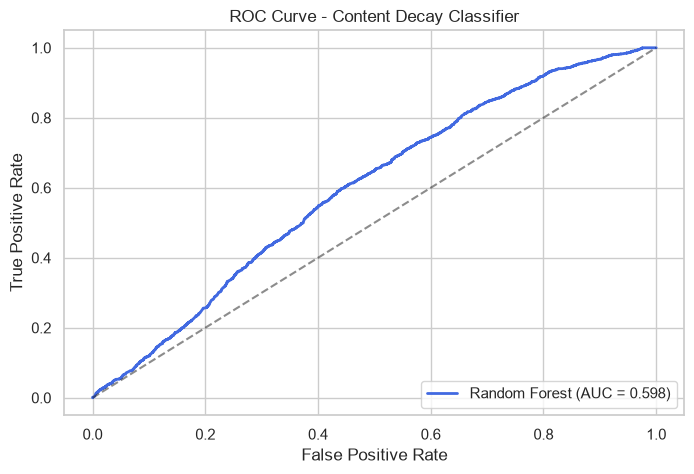

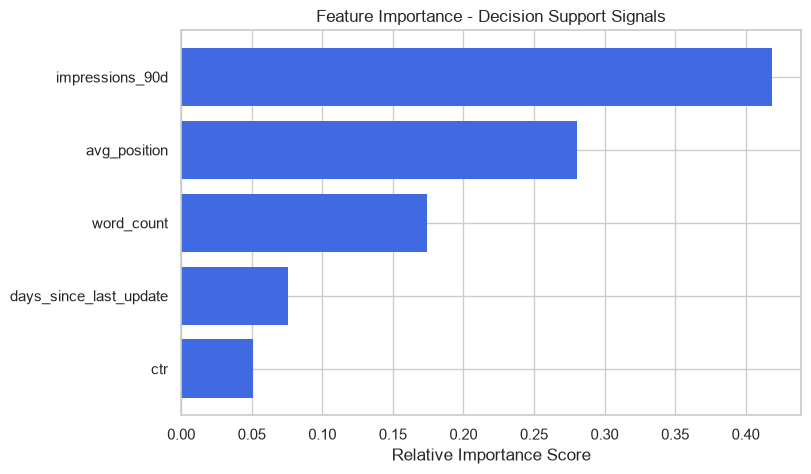

In [12]:
import os
import matplotlib.pyplot as plt

# Go up one directory to reach the root 'work/' folder
os.makedirs("../figures", exist_ok=True)

# 1. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, model_probs)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_val, model_probs):.3f})", color="royalblue", lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Content Decay Classifier")
plt.legend(loc="lower right")
plt.savefig("../figures/roc_curve.png", dpi=300, bbox_inches="tight")  # Updated path
plt.show()

# 2. Plot Feature Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features_ranked = [FEATURE_COLS[i] for i in indices]

plt.figure(figsize=(8, 5))
plt.barh(features_ranked[::-1], importances[indices][::-1], color="royalblue", edgecolor="none")
plt.xlabel("Relative Importance Score")
plt.title("Feature Importance - Decision Support Signals")
plt.savefig("../figures/feature_importances.png", dpi=300, bbox_inches="tight")  # Updated path
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
